In [1]:
import pandas as pd
import os
import numpy as np

In [3]:
year=2016

In [4]:
nis_path = f'data/NIS{year}_Village_Year_Coords.xlsx'
nis = pd.read_excel(nis_path)
nis.head()

,VillGis,Province,District,Commune,Village,XPHUM,YPHUM,Year,1-FAMILY,3-MAL_TOT,...,1449-T_Fe_Por_6-11,1450-Souy_Fami,1451-T_Soury_Indig,1452-T_Fe_Soury_Indig,1453-T_Soury_6-11,1454-T_Fe_Soury_6-11,1455-T_Oth_Indig,1456-T_Fe_Oth_Indig,1457-T_Oth_6-11,1458-T_Fe_Oth_6-11
0,1020101,Banteay Meanchey,Mongkol Borei,Banteay Neang,Ou Thum,287800.0,1494700.0,2016,196.0,431.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1020102,Banteay Meanchey,Mongkol Borei,Banteay Neang,Phnum,285900.0,1494700.0,2016,337.0,623.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1020103,Banteay Meanchey,Mongkol Borei,Banteay Neang,Banteay Neang,285900.0,1494300.0,2016,495.0,1102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1020104,Banteay Meanchey,Mongkol Borei,Banteay Neang,Kouk Pnov,284900.0,1493500.0,2016,209.0,439.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1020105,Banteay Meanchey,Mongkol Borei,Banteay Neang,Trang,285000.0,1494100.0,2016,207.0,470.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#Total population per village
nis["511-POP"] = nis["3-MAL_TOT"] + nis["2-FEM_TOT"]
nis.head()

,VillGis,Province,District,Commune,Village,XPHUM,YPHUM,Year,1-FAMILY,3-MAL_TOT,...,1450-Souy_Fami,1451-T_Soury_Indig,1452-T_Fe_Soury_Indig,1453-T_Soury_6-11,1454-T_Fe_Soury_6-11,1455-T_Oth_Indig,1456-T_Fe_Oth_Indig,1457-T_Oth_6-11,1458-T_Fe_Oth_6-11,511-POP
0,1020101,Banteay Meanchey,Mongkol Borei,Banteay Neang,Ou Thum,287800.0,1494700.0,2016,196.0,431.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,863.0
1,1020102,Banteay Meanchey,Mongkol Borei,Banteay Neang,Phnum,285900.0,1494700.0,2016,337.0,623.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1230.0
2,1020103,Banteay Meanchey,Mongkol Borei,Banteay Neang,Banteay Neang,285900.0,1494300.0,2016,495.0,1102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2244.0
3,1020104,Banteay Meanchey,Mongkol Borei,Banteay Neang,Kouk Pnov,284900.0,1493500.0,2016,209.0,439.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,874.0
4,1020105,Banteay Meanchey,Mongkol Borei,Banteay Neang,Trang,285000.0,1494100.0,2016,207.0,470.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,905.0


## Education module

In [6]:
#Illiterate population per village (women and men among 15 and 45 years)
nis["512-ILLITERATE_POP"] = nis["74-M_ILT15_17"] + nis["241-M_ILT18_24"]+nis["243-M_ILT25_35"]+nis["245-M_ILT36_45"] + nis["79-F_ILT15_17"]+nis["242-F_ILT18_24"]+nis["244-F_ILT25_35"]+nis["246-F_ILT36_45"]
nis["512-ILLITERATE_POP"].describe()

count    14431.000000
mean        32.474811
std         63.612752
min          0.000000
25%          0.000000
50%          7.000000
75%         38.000000
max       1557.000000
Name: 512-ILLITERATE_POP, dtype: float64

In [7]:
#Illiterate population rate per village
nis["513-ILLITERATE_RATE"] = (nis["512-ILLITERATE_POP"]/nis["511-POP"])*100
nis["511-POP"].describe()

#Comments: Literacy rate for youth and adult population is 91% and 86% in 2016 (https://uis.unesco.org/sites/default/files/documents/fs45-literacy-rates-continue-rise-generation-to-next-en-2017_0.pdf)
    #So there's two options: take the mean of adult and youth (11.5%) and take it as the threshold criteria for deprivation or divide it for age groups

count    14431.000000
mean      1074.956344
std        822.949912
min         24.000000
25%        572.500000
50%        869.000000
75%       1306.000000
max      12788.000000
Name: 511-POP, dtype: float64

In [8]:
print((nis["513-ILLITERATE_RATE"] == 0).sum())
print(nis["513-ILLITERATE_RATE"].isna().sum())

5719
7


## Health
### Child mortality

In [10]:
#Child mortality rate must be below 3.8%, the global rate between 2000-2015. Source:https://data.unicef.org/topic/child-survival/under-five-mortality/#:~:text=The%20global%20under%2Dfive%20mortality,a%20matter%20of%20urgent%20concern.

#Child mortality rate per village

nis["522-POB_UD5yrs"]=nis["201-MAL_0_2"]+nis["202-FEM_0_2"]+nis["203-MAL_3_4"]+nis["204-FEM_3_4"]+nis["205-MAL_5"]+nis["206-FEM_5"]
nis["523-C_MORT_RATE"]=nis["373-TOT_UD5_die"]/nis["522-POB_UD5yrs"]*100
pd.set_option("display.float_format", "{:.6f}".format)

nis["523-C_MORT_RATE"].describe()

count   14430.000000
mean        0.075286
std         0.414764
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        12.121212
Name: 523-C_MORT_RATE, dtype: float64

In [11]:
print((nis["366-KM_Heal_cent"] == 0).sum())
print(nis["366-KM_Heal_cent"].isna().sum())

930
7


## Living standards module
### Drinking water

In [12]:
#The deprivation threshold criteria will be under 71% (average between 69 and 73, data of 2015 and 2022 data), in which the village has less than a 71% of families with improved sources of water rate, it's considered deprived
    #Source: https://sdgs.un.org/goals/goal6#progress_and_info


#Source of drinking water is improved (purified systems, pump, mixed wells) or unimproved (pond, river, lakes, natural ponds, etc)

nis["514-IMPROV_WAT"] = nis["391-Wat_pur"] + nis["392-Wat_well"]
#Family responses related to source of drinking water 
nis["524-Fam_Wat_Res"]=nis["391-Wat_pur"] + nis["392-Wat_well"]+nis["394-Wat_pond"] + nis["396-Wat_river"]

#Rate of families with improved water 
nis["515-IMPROV_WAT_RATE"]=nis["514-IMPROV_WAT"]/nis["1-FAMILY"]*100
nis["516-UNIMPROV_WAT"] = nis["394-Wat_pond"] + nis["1-FAMILY"]

#Rate of families with unimproved water 
nis["517-UNIMPROV_WAT_RATE"]=nis["516-UNIMPROV_WAT"]/nis["1-FAMILY"]*100
nis.head()

,VillGis,Province,District,Commune,Village,XPHUM,YPHUM,Year,1-FAMILY,3-MAL_TOT,...,511-POP,512-ILLITERATE_POP,513-ILLITERATE_RATE,522-POB_UD5yrs,523-C_MORT_RATE,514-IMPROV_WAT,524-Fam_Wat_Res,515-IMPROV_WAT_RATE,516-UNIMPROV_WAT,517-UNIMPROV_WAT_RATE
0,1020101,Banteay Meanchey,Mongkol Borei,Banteay Neang,Ou Thum,287800.000000,1494700.000000,2016,196.000000,431.000000,...,863.000000,37.000000,4.287370,81.000000,0.000000,0.000000,196.000000,0.000000,243.000000,123.979592
1,1020102,Banteay Meanchey,Mongkol Borei,Banteay Neang,Phnum,285900.000000,1494700.000000,2016,337.000000,623.000000,...,1230.000000,11.000000,0.894309,137.000000,0.000000,120.000000,324.000000,35.608309,541.000000,160.534125
2,1020103,Banteay Meanchey,Mongkol Borei,Banteay Neang,Banteay Neang,285900.000000,1494300.000000,2016,495.000000,1102.000000,...,2244.000000,0.000000,0.000000,211.000000,0.000000,257.000000,449.000000,51.919192,601.000000,121.414141
3,1020104,Banteay Meanchey,Mongkol Borei,Banteay Neang,Kouk Pnov,284900.000000,1493500.000000,2016,209.000000,439.000000,...,874.000000,3.000000,0.343249,70.000000,0.000000,53.000000,209.000000,25.358852,221.000000,105.741627
4,1020105,Banteay Meanchey,Mongkol Borei,Banteay Neang,Trang,285000.000000,1494100.000000,2016,207.000000,470.000000,...,905.000000,0.000000,0.000000,103.000000,0.000000,39.000000,174.000000,18.840580,342.000000,165.217391


In [13]:
print((nis["514-IMPROV_WAT"] == 0).sum())
print(nis["514-IMPROV_WAT"].isna().sum())

1718
7


In [14]:
print((nis["515-IMPROV_WAT_RATE"] == 0).sum())
print(nis["515-IMPROV_WAT_RATE"].isna().sum())

1718
7


In [15]:
nis["515-IMPROV_WAT_RATE"].describe()

count   14431.000000
mean       60.236421
std        38.692633
min         0.000000
25%        21.680812
50%        69.953052
75%       100.000000
max       100.000000
Name: 515-IMPROV_WAT_RATE, dtype: float64

In [83]:
#Creating dummy for variable of unimproved source of water (517-FAM_UNIMPROV_WAT_RATE)
    # takes the value of 1 if more than 50% of the families have an unimproved sources of water

#nis["525-UNIMPROV_WAT_DUM"] = (nis["517-FAM_UNIMPROV_WAT_RATE"] >= 50).astype(int)
#nis["525-UNIMPROV_WAT_DUM"].describe()

### Electricity

In [16]:
#Global electricity access in 2022 is 91% (https://sdgs.un.org/goals/goal7#progress_and_info)

#Rate of houses that have electricity
nis["528-Elec_Rate"]=nis["330-Villa_R_Elec"] / nis["1-FAMILY"]*100

nis.describe()

,VillGis,XPHUM,YPHUM,Year,1-FAMILY,3-MAL_TOT,2-FEM_TOT,73-F_HHH,201-MAL_0_2,202-FEM_0_2,...,512-ILLITERATE_POP,513-ILLITERATE_RATE,522-POB_UD5yrs,523-C_MORT_RATE,514-IMPROV_WAT,524-Fam_Wat_Res,515-IMPROV_WAT_RATE,516-UNIMPROV_WAT,517-UNIMPROV_WAT_RATE,528-Elec_Rate
count,14438.000000,12206.000000,12206.000000,14438.000000,14431.000000,14431.000000,14431.000000,14431.000000,14431.000000,14431.000000,...,14431.000000,14431.000000,14431.000000,14430.000000,14431.000000,14431.000000,14431.000000,14431.000000,14431.000000,14431.000000
mean,11536955.725239,464577.893823,1335544.392594,2016.000000,236.206223,527.851015,547.105329,35.119188,24.133809,23.917954,...,32.474811,3.428323,129.435174,0.075286,147.245167,195.076641,60.236421,259.899314,111.604805,0.293693
std,7297064.852287,98885.356654,108995.177447,0.000000,172.310572,409.442506,419.903946,36.826823,22.285669,22.134236,...,63.612752,6.006045,116.053157,0.414764,166.186085,167.836385,38.692633,190.691075,25.179925,2.388338
min,1020101.000000,0.000000,0.000000,2016.000000,8.000000,18.000000,6.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,100.000000,0.000000
25%,5050409.250000,415746.750000,1247990.000000,2016.000000,127.000000,278.000000,292.000000,15.000000,11.000000,11.000000,...,0.000000,0.000000,63.000000,0.000000,35.000000,92.000000,21.680812,139.000000,100.000000,0.000000
50%,12020408.500000,471442.000000,1303610.000000,2016.000000,194.000000,425.000000,443.000000,25.000000,19.000000,19.000000,...,7.000000,0.825206,100.000000,0.000000,107.000000,157.000000,69.953052,211.000000,100.000000,0.000000
75%,17100702.750000,521395.000000,1426434.250000,2016.000000,292.000000,643.000000,666.000000,43.000000,30.000000,30.000000,...,38.000000,4.191184,160.000000,0.000000,200.000000,248.000000,100.000000,323.000000,106.819024,0.000000
max,25071415.000000,770884.000000,1594700.000000,2016.000000,2678.000000,6656.000000,7345.000000,685.000000,518.000000,697.000000,...,1557.000000,55.903272,2753.000000,12.121212,2678.000000,2678.000000,100.000000,2731.000000,200.000000,94.690265


In [86]:
#Creating a dummy for village houses with electricity (330-Villa_R_Elec), 
    # takes the value of 1 if none village houses has electricity

#nis["330-Villa_R_Elec"].describe()
#nis["523-Elec_DUM"]= (nis["330-Villa_R_Elec"] == 0).astype(int)
 

### Housing quality (roof)

In [17]:
#Materials of roof are High Quality (tiled and zinc or fibro) or Low Quality (Thatched) among houses that have electricity
nis["518-HQ_ROOF"]=nis["326-Z_Fib_R_Elec"] + nis["327-Til_R_Elec"]

#Total of roof materials 
nis["525-TOT_ROOF"]=nis["326-Z_Fib_R_Elec"] + nis["327-Til_R_Elec"]+nis["325-THAT_R_Elec"]

#Rate of High Quality (HQ) roofs 
# nis["519-HQ_ROOF_RATE"]=nis["518-HQ_ROOF"] / nis["525-TOT_ROOF"]*100

#Rate of Low Quality (LQ) roofs 
# nis["526-LQ_ROOF_RATE"]=nis["325-THAT_R_Elec"] / nis["525-TOT_ROOF"]*100

#Only about 66% of housing units are built with durable material for roof, wall, or floor (p. 19 - https://documents1.worldbank.org/curated/en/370141635794493951/pdf/Introducing-the-Adequate-Housing-Index-AHI-A-New-Approach-to-Estimate-the-Adequate-Housing-Deficit-within-and-across-Emerging-Economies.pdf)
# And electricity access is 91% https://sdgs.un.org/goals/goal7#progress_and_info

#Rate of High Quality (HQ) roofs with electricity
nis["533-HQ_ROOF_ELEC_RATE"]=(nis["518-HQ_ROOF"] / nis["1-FAMILY"])*100
nis["534-LQ_ROOF_ELEC_RATE"]=(nis["325-THAT_R_Elec"] / nis["1-FAMILY"])*100

nis["534-LQ_ROOF_ELEC_RATE"].describe()

count   14431.000000
mean        0.812840
std         3.267700
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        57.575758
Name: 534-LQ_ROOF_ELEC_RATE, dtype: float64

In [18]:
print((nis["533-HQ_ROOF_ELEC_RATE"] == 0).sum())
print(nis["533-HQ_ROOF_ELEC_RATE"].isna().sum())

2919
7


In [19]:
nis["1-FAMILY"].describe()

count   14431.000000
mean      236.206223
std       172.310572
min         8.000000
25%       127.000000
50%       194.000000
75%       292.000000
max      2678.000000
Name: 1-FAMILY, dtype: float64

In [91]:
#Creating dummy for variable of low quality materials of roof (526-LQ_ROOF)
    # takes the value of 1 if more than 50% of the families have roof with low quality materials
#nis["527-LQ_ROOF_DUM"] = (nis["526-LQ_ROOF"] >= 50).astype(int)

#nis["527-LQ_ROOF_DUM"].describe()

### Assets ownership

In [20]:
#### Mobility assets 
    #Assets considered by NIS (moto and motor tri-cycle) 
nis["520-MOB_ASSETS"] = nis["30-MOTO_NUM"] + nis["355-Mot_Tricyc_NUM"]
nis["521-MOB_ASSETS_RATE"]=nis["520-MOB_ASSETS"]/nis["511-POP"]*100

#Families that own an cultivated land
nis["529-CULT_LAND"] = nis["1-FAMILY"] - nis["289-No_F_Land"]

### Agricultural assets (number of families that have irrigation wells, pigs, goat/sheep, chicken, duck, crocodiles, own cultivated land). 
nis["530-AGRI_ASSETS"] = nis["529-CULT_LAND"] + nis["282-Own_IRRI_Wells"]+nis["297-Goat_fami"]+nis["299-Chick_fami"]+nis["302-Duck_fami"]+nis["316-Croco_fami"]
nis["531-AGRI_ASSETS_RATE"]=nis["530-AGRI_ASSETS"]/nis["1-FAMILY"]*100
        #Revisar  
nis["531-AGRI_ASSETS_RATE"].describe()


count   14431.000000
mean      154.917563
std        52.536205
min         0.000000
25%       110.063143
50%       161.739130
75%       195.476250
max       344.791667
Name: 531-AGRI_ASSETS_RATE, dtype: float64

In [21]:
print((nis["521-MOB_ASSETS_RATE"] == 0).sum())
print(nis["521-MOB_ASSETS_RATE"].isna().sum())

110
7


In [22]:

nis["521-MOB_ASSETS_RATE"].describe()

count   14431.000000
mean       15.479424
std         7.690354
min         0.000000
25%        10.530859
50%        14.931396
75%        19.761386
max       219.120879
Name: 521-MOB_ASSETS_RATE, dtype: float64

### Sanitation

In [23]:
#Rate of houses that have latrines
nis["532-Sanit_Rate"]=100-(nis["23-TOILET"] / nis["1-FAMILY"]*100)
nis.head()

,VillGis,Province,District,Commune,Village,XPHUM,YPHUM,Year,1-FAMILY,3-MAL_TOT,...,518-HQ_ROOF,525-TOT_ROOF,533-HQ_ROOF_ELEC_RATE,534-LQ_ROOF_ELEC_RATE,520-MOB_ASSETS,521-MOB_ASSETS_RATE,529-CULT_LAND,530-AGRI_ASSETS,531-AGRI_ASSETS_RATE,532-Sanit_Rate
0,1020101,Banteay Meanchey,Mongkol Borei,Banteay Neang,Ou Thum,287800.000000,1494700.000000,2016,196.000000,431.000000,...,139.000000,139.000000,70.918367,0.000000,74.000000,8.574739,196.000000,300.000000,153.061224,34.693878
1,1020102,Banteay Meanchey,Mongkol Borei,Banteay Neang,Phnum,285900.000000,1494700.000000,2016,337.000000,623.000000,...,275.000000,275.000000,81.602374,0.000000,337.000000,27.398374,327.000000,366.000000,108.605341,43.620178
2,1020103,Banteay Meanchey,Mongkol Borei,Banteay Neang,Banteay Neang,285900.000000,1494300.000000,2016,495.000000,1102.000000,...,350.000000,350.000000,70.707071,0.000000,338.000000,15.062389,495.000000,791.000000,159.797980,26.262626
3,1020104,Banteay Meanchey,Mongkol Borei,Banteay Neang,Kouk Pnov,284900.000000,1493500.000000,2016,209.000000,439.000000,...,100.000000,100.000000,47.846890,0.000000,105.000000,12.013730,174.000000,232.000000,111.004785,45.933014
4,1020105,Banteay Meanchey,Mongkol Borei,Banteay Neang,Trang,285000.000000,1494100.000000,2016,207.000000,470.000000,...,186.000000,186.000000,89.855072,0.000000,180.000000,19.889503,127.000000,127.000000,61.352657,42.028986


In [24]:
print((nis["532-Sanit_Rate"] == 0).sum())
print(nis["532-Sanit_Rate"].isna().sum())

1503
7


In [25]:
nis["532-Sanit_Rate"].describe()

count   14431.000000
mean       40.501950
std        29.059355
min         0.000000
25%        14.478221
50%        39.485981
75%        63.004647
max       100.000000
Name: 532-Sanit_Rate, dtype: float64

In [26]:
#The year needs to be change
file_path=f"data/NISAddRates_{year}.xlsx"
nis.to_excel(file_path, index=False)

In [27]:
nis["513-ILLITERATE_RATE"].describe()

count   14431.000000
mean        3.428323
std         6.006045
min         0.000000
25%         0.000000
50%         0.825206
75%         4.191184
max        55.903272
Name: 513-ILLITERATE_RATE, dtype: float64

In [28]:
nis["523-C_MORT_RATE"].describe()

count   14430.000000
mean        0.075286
std         0.414764
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        12.121212
Name: 523-C_MORT_RATE, dtype: float64

In [29]:
nis["373-TOT_UD5_die"].describe()

count   14431.000000
mean        0.083016
std         0.431323
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        19.000000
Name: 373-TOT_UD5_die, dtype: float64

In [30]:
pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None) 

print(nis.isna().sum())

VillGis                               0
Province                              0
District                              0
Commune                               0
Village                               0
XPHUM                              2232
YPHUM                              2232
Year                                  0
1-FAMILY                              7
3-MAL_TOT                             7
2-FEM_TOT                             7
73-F_HHH                              7
201-MAL_0_2                           7
202-FEM_0_2                           7
203-MAL_3_4                           7
204-FEM_3_4                           7
205-MAL_5                             7
206-FEM_5                             7
207-MAL_6                             7
208-FEM_6                             7
209-MAL_7_11                          7
210-FEM_7_11                          7
211-MAL_12_14                         7
212-FEM_12_14                         7
213-MAL_15_17                         7


<Axes: >

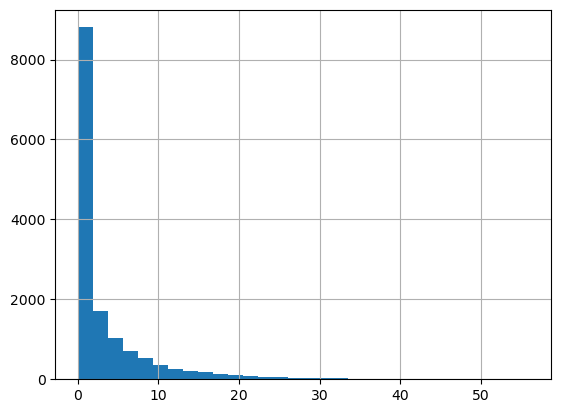

In [31]:
nis = nis[nis["513-ILLITERATE_RATE"].notna()]  # Elimina NaN
nis = nis[nis["513-ILLITERATE_RATE"] != np.inf] 
nis["513-ILLITERATE_RATE"].hist(bins=30)